# MNIST Handwritten Digit Classification
## TensorFlow + Keras

**Assignment 2**

This notebook loads the MNIST handwritten digit dataset, builds a neural network using TensorFlow/Keras, evaluates the model, visualizes training results, predicts five test images, and performs an experiment by changing the number of neurons.

## 1. Import Required Libraries

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

## 2. Load MNIST Dataset

In [5]:
# Load MNIST dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (60000, 28, 28)
Testing data: (10000, 28, 28)


## 3. Display Sample Images

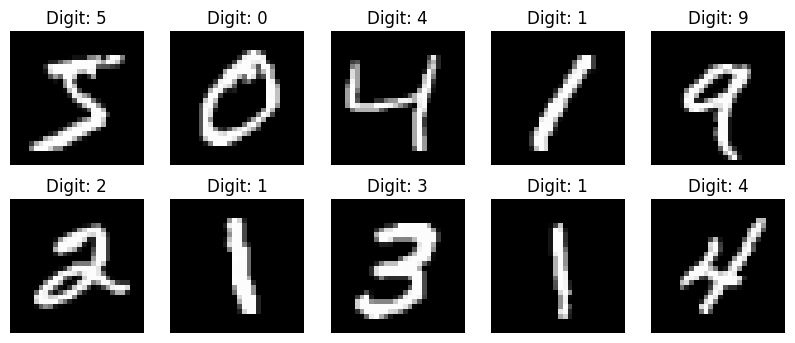

In [6]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title("Digit: " + str(y_train[i]))
    plt.axis("off")

plt.show()

## 4. Normalize Images

The original MNIST pixel values range from 0 to 255. Dividing by 255 converts them to values between 0 and 1.

In [7]:

x_train = x_train / 255.0
x_test = x_test / 255.0

## 5. Create the Neural Network

In [8]:
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Model Architecture

- **Flatten:** Converts the 28×28 image into 784 values.
- **Dense 128:** First hidden layer with ReLU activation.
- **Dense 64:** Second hidden layer with ReLU activation.
- **Dense 10:** Output layer representing digits 0–9 using Softmax.

## 6. Compile the Model

In [9]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 7. Display Model Summary

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

## 8. Train the Model

In [11]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9255 - loss: 0.2539 - val_accuracy: 0.9733 - val_loss: 0.0999
Epoch 2/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9685 - loss: 0.1041 - val_accuracy: 0.9750 - val_loss: 0.0890
Epoch 3/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9775 - loss: 0.0725 - val_accuracy: 0.9752 - val_loss: 0.0859
Epoch 4/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9819 - loss: 0.0555 - val_accuracy: 0.9770 - val_loss: 0.0817
Epoch 5/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9859 - loss: 0.0437 - val_accuracy: 0.9772 - val_loss: 0.0813
Epoch 6/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9885 - loss: 0.0354 - val_accuracy: 0.9742 - val_loss: 0.0909
Epoch 7/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9916 - loss: 0.0281 - val_accuracy: 0.9768 - val_loss: 0.0881
Epoch 8/10
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.9912 - loss: 0.025

## 9. Evaluate the Model on Test Data

In [12]:
test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("TEST RESULTS")
print("==============================")
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)


TEST RESULTS
Test Loss: 0.0961693525314331
Test Accuracy: 0.9768999814987183


## 10. Training and Validation Accuracy

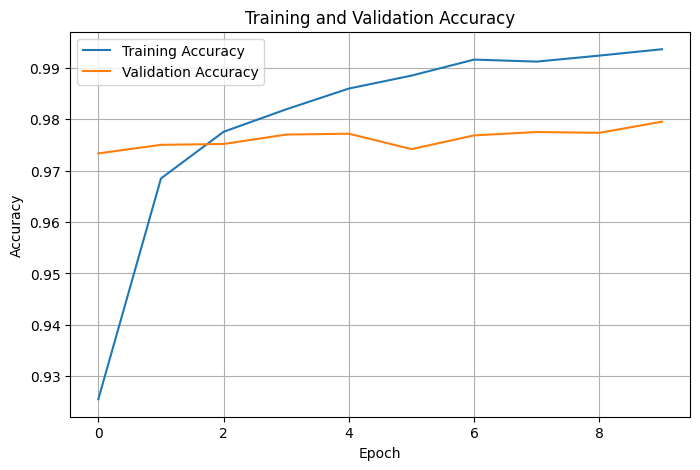

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.show()

## 11. Training and Validation Loss

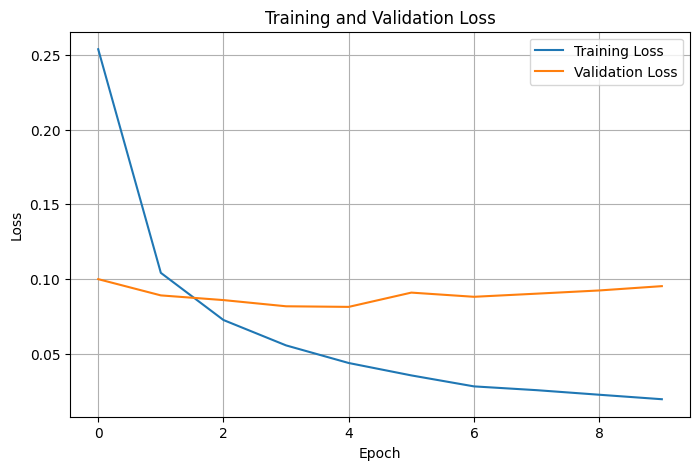

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.show()

## 12. Predict Five Test Images

In [15]:
predictions = model.predict(x_test[:5])
predicted_labels = np.argmax(predictions, axis=1)

print("\n==============================")
print("5 IMAGE PREDICTIONS")
print("==============================")

for i in range(5):
    print(
        "Image", i + 1,
        "| Actual:", y_test[i],
        "| Predicted:", predicted_labels[i]
    )

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step

5 IMAGE PREDICTIONS
Image 1 | Actual: 7 | Predicted: 7
Image 2 | Actual: 2 | Predicted: 2
Image 3 | Actual: 1 | Predicted: 1
Image 4 | Actual: 0 | Predicted: 0
Image 5 | Actual: 4 | Predicted: 4


## 13. Display the Five Predictions

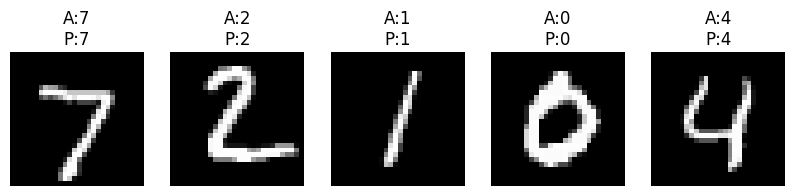

In [16]:
plt.figure(figsize=(10, 2))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(
        f"A:{y_test[i]}\nP:{predicted_labels[i]}"
    )
    plt.axis("off")

plt.show()

# 14. Experiment
## Change First Hidden Layer: 128 → 256 Neurons

The original model uses 128 neurons in the first hidden layer. In the experiment, this is increased to 256 neurons while keeping the other settings unchanged.

In [17]:
experiment_model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28, 28)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

## 15. Compile the Experimental Model

In [18]:
experiment_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 16. Train the Experimental Model

In [ ]:
experiment_model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/10
 897/1688 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.8471 - loss: 0.5266

## 17. Evaluate the Experimental Model

In [ ]:
experiment_loss, experiment_accuracy = experiment_model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\n==============================")
print("EXPERIMENT RESULTS")
print("==============================")
print("Original model accuracy:",
      test_accuracy)

print("Experiment accuracy:",
      experiment_accuracy)

## 18. Final Result

The original model and experimental model accuracies printed above should be recorded in the report.

**Original architecture:** 784 → 128 → 64 → 10

**Experimental architecture:** 784 → 256 → 64 → 10